In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import copy
import torch.nn.functional as F
from tqdm import tqdm

In [25]:
# Device setup - en üste ekle
if torch.cuda.is_available():
    device = "cuda:0"
    dtype = torch.cuda.FloatTensor
elif torch.backends.mps.is_available():
    device = "mps"
    dtype = torch.FloatTensor
else:
    device = "cpu"
    dtype = torch.FloatTensor

print("Using device:", device)

Using device: mps


# Dataset
Load dataset

In [3]:
train_images = np.load('dermamnist_128/train_images.npy')
train_labels = np.load('dermamnist_128/train_labels.npy')

val_images = np.load('dermamnist_128/val_images.npy')
val_labels = np.load('dermamnist_128/val_labels.npy')

test_images = np.load('dermamnist_128/test_images.npy')
test_labels = np.load('dermamnist_128/test_labels.npy')

Check shape of your data

In [4]:
print('Train images size:', train_images.shape)
print('Train labels size:', train_labels.shape)
print('')
print('Validation images size:',val_images.shape)
print('Validation images size:',val_labels.shape)
print('')
print('Test images size:',test_images.shape)
print('Test images size:',test_labels.shape)

Train images size: (7007, 128, 128, 3)
Train labels size: (7007, 1)

Validation images size: (1003, 128, 128, 3)
Validation images size: (1003, 1)

Test images size: (2005, 128, 128, 3)
Test images size: (2005, 1)


**Classes**  
0 : akiec, Actinic keratoses and intraepithelial carcinoma / Bowen's disease  
1 : bcc, basal cell carcinoma (bcc)  
2 : bkl, benign keratosis-like lesions (solar lentigines / seborrheic keratoses and lichen-planus like keratoses)   
3 : df, dermatofibroma (df)  
4 : nv, melanocytic nevi  
5 : vasc, vascular lesions (angiomas, angiokeratomas, pyogenic granulomas and hemorrhage)  
6 : mel, melanoma  

In [5]:
classDict = {0 : 'akiec',
1 : 'bcc',
2 : 'bkl',
3 : 'df',
4 : 'nv',
5 : 'vasc',
6 : 'mel'}

### Visualize Random Samples

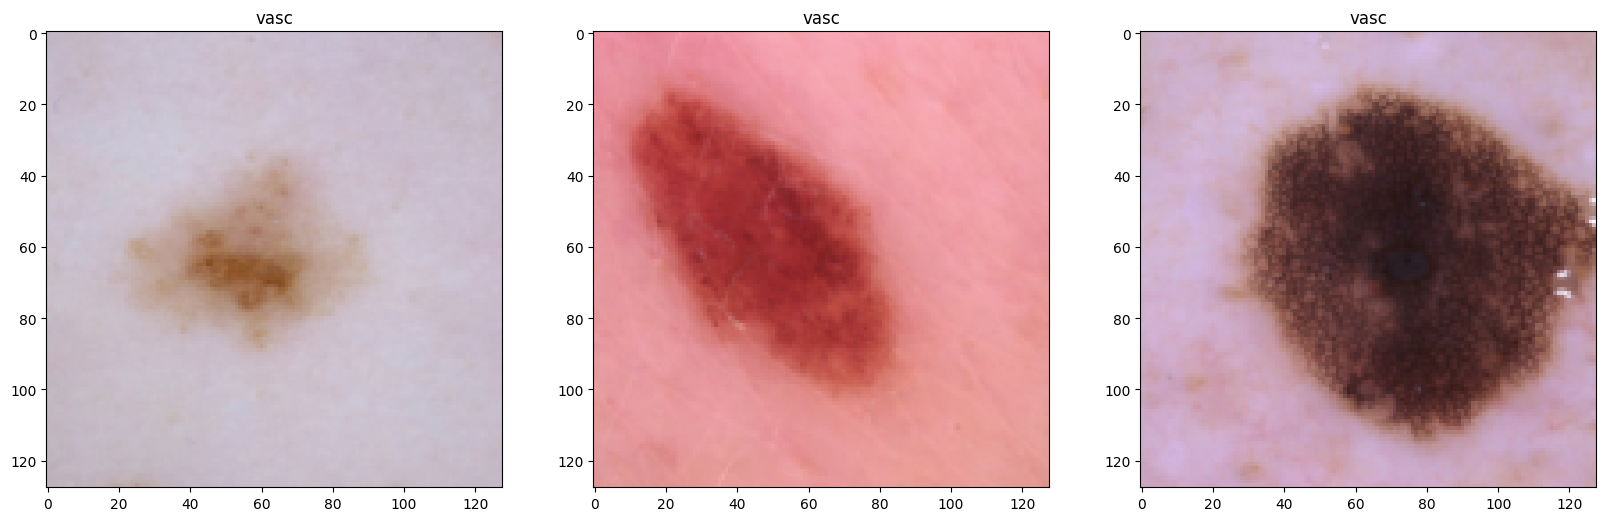

In [6]:
fig, axs = plt.subplots(1, 3)
fig.set_figheight(8)
fig.set_figwidth(20)
selected_indices = np.random.randint(0, high=len(train_images), size=3)
for i in range(0,3):
    axs[i].imshow(train_images[selected_indices[i]])
    axs[i].title.set_text(classDict[train_labels[selected_indices[i]].item()])

### Plot class distribution of your data.

#### TODO #####
class_names = list(classDict.values())
class_counts = [(train_labels == i).sum() for i in range(7)]

plt.figure(figsize=(10, 5))
plt.bar(class_names, class_counts, color='steelblue')
plt.title('Class Distribution in Training Set')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
for i, count in enumerate(class_counts):
    plt.text(i, count + 10, str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("Class counts:", dict(zip(class_names, class_counts)))

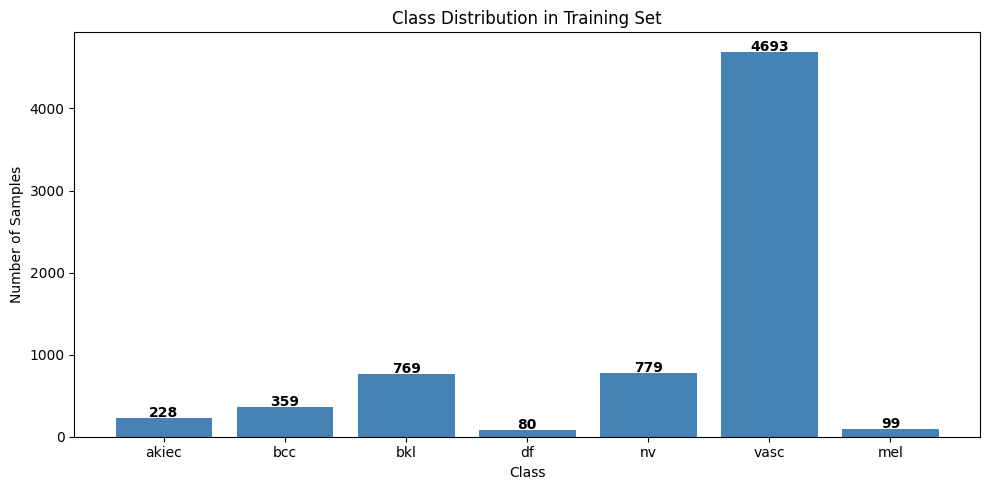

Class counts: {'akiec': np.int64(228), 'bcc': np.int64(359), 'bkl': np.int64(769), 'df': np.int64(80), 'nv': np.int64(779), 'vasc': np.int64(4693), 'mel': np.int64(99)}


In [7]:
#### TODO #####
class_names = list(classDict.values())
class_counts = [(train_labels == i).sum() for i in range(7)]

plt.figure(figsize=(10, 5))
plt.bar(class_names, class_counts, color='steelblue')
plt.title('Class Distribution in Training Set')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
for i, count in enumerate(class_counts):
    plt.text(i, count + 10, str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("Class counts:", dict(zip(class_names, class_counts)))

### Create Dataset Class 

In [14]:
class DermoDataset(Dataset):
    def __init__(self, images, labels, classDict, input_size=(128,128), augmentation=False):
        super(DermoDataset, self).__init__()
        self.image_list = images
        self.label_list = labels
        self.augmentation = augmentation
        self.classDict = classDict
        self.height = input_size[0]
        self.width = input_size[1]
        
    def transform(self, img, label):
        #### TODO ####
        #### Normalization, Augmentation, Tensor Conversion, Image Resizing #####
        # Convert to tensor to channel height width
        img = torch.tensor(img.copy(), dtype=torch.float32)  # copy() fixes numpy read-only issue
        img = img.permute(2, 0, 1)
        # normalize the image then standardize
        img = img/255.0
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        img = (img - mean) / std
        # resize to target size
        img = torch.nn.functional.interpolate( # interpolating is for our target size needed for ViT
            img.unsqueeze(0),
            size=(self.height, self.width)
        ).squeeze(0) #removes the fake batch dimension we added for interpolating (it just needed it) (1, 3, 128, 128)  →  (3, 128, 128)
        
        # in augmentation we flip the images randomly 
        if self.augmentation:
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[2]) #horizontal flip
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[1]) #vertical flip
            
        label = torch.tensor(label.copy(), dtype=torch.long).squeeze() # cross entropy loss specificlly requires labels as 64bit integers long
        return img, label

    def __getitem__(self, index):
        #### TODO ####
        # read image and label with index #
        current_image = self.image_list[index]
        current_label = self.label_list[index]
        
        # transform
        current_image, current_label = self.transform(current_image, current_label)
        

        return current_image, current_label

    def __len__(self):
        #### TODO ####
        return len(self.image_list)
        

In [15]:
train_dataset = DermoDataset(train_images, train_labels, classDict)
val_dataset = DermoDataset(val_images, val_labels, classDict)
print('Train set size:', len(train_dataset))
print('Val set size:', len(val_dataset))

Train set size: 7007
Val set size: 1003


### Create DataLoader
You should tune batch size

In [19]:
batch_size = 32
#### TODO ####
train_loader = DataLoader(train_dataset,batch_size=batch_size, shuffle=True)

val_loader = DataLoader(val_dataset,batch_size=batch_size, shuffle=False)

In [20]:
dataloaders = {
    'train': train_loader,
    'val': val_loader
}

In [21]:
# Check one batch
images, labels = next(iter(train_loader))
print(images.shape)  # should be (32, 3, 128, 128)
print(labels.shape)  # should be (32,)

torch.Size([32, 3, 128, 128])
torch.Size([32])


# Create CNN Model 

In [22]:
class SimpleCNN(torch.nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        #### TODO ####
        # are there edges, are there color transitions -> 32 feature map
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3,padding=1)
        # is there a shape made by these edges
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        # is this shape actually like a lesion
        self.conv3 = nn.Conv2d(in_channels=64,out_channels=128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # fully connected layers 
        # flatten to pass into function 
        # learn from combinations 
        self.fc1 = nn.Linear(128*16*16, 256)
        # drop some neurons to prevent overfitting 
        self.dropout = nn.Dropout(p=0.5)
        # decide the class 
        self.fc2 = nn.Linear(256, 7) # since we have 7 classes 
    def forward(self, x):
        #### TODO ####
        x = self.pool(F.relu(self.conv1(x))) # F refers to functional of nn
        x = self.pool(F.relu(self.conv2(x)))  
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        # FC layers
        x = F.relu(self.fc1(x))               # (B,32768) → (B,256)
        x = self.dropout(x)
        x = self.fc2(x)                        # (B,256) → (B,7)
        return x

In [26]:
model = SimpleCNN()
model.to(device=device)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32768, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=7, bias=True)
)

# Transfer Learning

In [27]:
class ResNet50Classifier(nn.Module):
    def __init__(
            self,
            ch,
            num_class,
            freeze
    ):
        super(ResNet50Classifier, self).__init__()
        #### TODO ####
        self.model = models.resnet50(weights='IMAGENET1K_V1')
        # Freeze pretrained layers if requested
        if freeze:
            for param in self.model.parameters():
                param.requires_grad = False

        # Replace final FC layer with our own (1000 classes → num_class)
        num_ftrs = self.model.fc.in_features  # 2048
        self.model.fc = nn.Linear(num_ftrs, num_class)
        # Handle grayscale input (1 channel instead of 3)
        if ch != 3:
            self.model.conv1 = nn.Conv2d(ch, 64, kernel_size=7, stride=2, padding=3, bias=False)


    def forward(self, x):
        #### TODO ####
        return self.model(x)

In [28]:
class Vit16Classifier(nn.Module):
    def __init__(
            self,
            ch,
            num_class,
            freeze
    ):
        super(Vit16Classifier, self).__init__()
        #### TODO ####
        # Load pretrained ViT
        self.model = models.vit_b_16(weights='IMAGENET1K_V1')
        
        # Freeze pretrained layers if requested
        if freeze:
            for param in self.model.parameters():
                param.requires_grad = False
        
        # Replace classification head (1000 classes → num_class)
        num_ftrs = self.model.heads.head.in_features  # 768
        self.model.heads.head = nn.Linear(num_ftrs, num_class)
        
        # Handle grayscale input
        if ch != 3:
            self.model.conv_proj = nn.Conv2d(ch, 768, kernel_size=16, stride=16)



    def forward(self, x):
        #### TODO ####

        return self.model(x)

In [30]:
model = ResNet50Classifier(3, 7, False)
model.to(device=device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/adayildiz/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:08<00:00, 12.0MB/s]


ResNet50Classifier(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
 

In [31]:
model = Vit16Classifier(3, 7, False)
model.to(device=device)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /Users/adayildiz/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:29<00:00, 11.8MB/s] 


Vit16Classifier(
  (model): VisionTransformer(
    (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (encoder): Encoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (layers): Sequential(
        (encoder_layer_0): EncoderBlock(
          (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (dropout): Dropout(p=0.0, inplace=False)
          (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): MLPBlock(
            (0): Linear(in_features=768, out_features=3072, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=3072, out_features=768, bias=True)
            (4): Dropout(p=0.0, inplace=False)
          )
        )
        (encoder_layer_1): EncoderBlock(
          (ln_1):

In [32]:
# ResNet test
model_resnet = ResNet50Classifier(3, 7, False)
dummy = torch.randn(4, 3, 128, 128)
out = model_resnet(dummy)
print("ResNet output:", out.shape)  # torch.Size([4, 7])

# ViT test - needs 224x224!
model_vit = Vit16Classifier(3, 7, False)
dummy_vit = torch.randn(4, 3, 224, 224)
out_vit = model_vit(dummy_vit)
print("ViT output:", out_vit.shape)  # torch.Size([4, 7])

ResNet output: torch.Size([4, 7])
ViT output: torch.Size([4, 7])


# Training

### Set Optimizer with parameters

In [33]:
lrRate = 1e-3
weightDecay = 1e-4
numberOfEpoch = 20
early_stop = 5
# device = "cuda:0"
# dtype = torch.cuda.FloatTensor
optimizer = optim.Adam(model.parameters(), lr=lrRate, weight_decay=weightDecay)

### Loss Function

In [37]:
# Weighted loss - class imbalance fix
class_counts = np.array([228, 359, 769, 80, 779, 4693, 99], dtype=np.float32)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * 7
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

calc_loss = nn.CrossEntropyLoss(weight=class_weights)

### Train Loop

In [41]:
def train(model, dataloaders, calc_loss, optimizer, numberOfEpoch, early_stop, device, dtype):
    best_model = copy.deepcopy(model.state_dict())
    best_loss = 1e7
    early_stop_counter = 0
    train_loss_list = []
    val_loss_list = []

    # total_memory = f'{torch.cuda.get_device_properties(0).total_memory/ 1E9 if torch.cuda.is_available() else 0:.3g}G'
    for epoch in range(0, numberOfEpoch):
        # Each epoch has a training and validation phase
        for phase in ['train','val']:
            epoch_loss = 0.0
            correct_prediction = 0.0
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()  # Set model to evaluate mode
            batch_step = 0
            batch_size = dataloaders[phase].batch_size
            with tqdm(dataloaders[phase], unit="batch") as tbar:
                for input_imgs, gt_labels in tbar:
                    tbar.set_description(f"Epoch {epoch}")
                    batch_step += 1
                    input_imgs = input_imgs.to(device=device, dtype=torch.float32)
                    gt_labels = gt_labels.to(device=device, dtype=torch.long)
    
                    #### TODO ####
                    if phase == 'train':
                        optimizer.zero_grad()           # gradients sıfırla
                        outputs = model(input_imgs)     # forward pass
                        loss = calc_loss(outputs, gt_labels)  # loss hesapla
                        loss.backward()                 # backpropagation
                        optimizer.step()                # weights güncelle
                    
                    #### VAL PHASE ####
                    else:
                        with torch.no_grad():           # gradient hesaplama
                            outputs = model(input_imgs)
                            loss = calc_loss(outputs, gt_labels)
                    
                    # Accuracy hesapla
                    preds = torch.argmax(outputs, dim=1)
                    correct_prediction += (preds == gt_labels).sum().item()
                    epoch_loss += loss.item()
                    
                    tbar.set_postfix(loss=epoch_loss/batch_step)
            # Epoch sonu
            avg_loss = epoch_loss / batch_step
            avg_acc = correct_prediction / len(dataloaders[phase].dataset)
            
            if phase == 'train':
                train_loss_list.append(avg_loss)
                print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Train Acc: {avg_acc:.4f}")
            
            else:
                val_loss_list.append(avg_loss)
                print(f"Epoch {epoch} | Val Loss:   {avg_loss:.4f} | Val Acc:   {avg_acc:.4f}")
                
                # Best model kaydet
                if avg_loss < best_loss:
                    best_loss = avg_loss
                    best_model = copy.deepcopy(model.state_dict())
                    early_stop_counter = 0
                    print(f"  ✓ Best model saved!")
                else:
                    early_stop_counter += 1
                    print(f"  No improvement {early_stop_counter}/{early_stop}")
                
                # Early stopping
                if early_stop_counter >= early_stop:
                    print(f"Early stopping at epoch {epoch}")
                    return best_model, train_loss_list, val_loss_list

    return best_model, train_loss_list, val_loss_list

In [42]:
model = SimpleCNN()
model.to(device=device)

class_counts = np.array([228, 359, 769, 80, 779, 4693, 99], dtype=np.float32)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * 7
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
calc_loss = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=lrRate, weight_decay=weightDecay)

best_model, train_loss_list, val_loss_list = train(
    model, dataloaders, calc_loss, optimizer, numberOfEpoch, early_stop, device, dtype
)

Epoch 0: 100%|██████████| 219/219 [00:08<00:00, 26.86batch/s, loss=1.76]


Epoch 0 | Train Loss: 1.7625 | Train Acc: 0.4213


Epoch 0: 100%|██████████| 32/32 [00:00<00:00, 52.51batch/s, loss=1.66]


Epoch 0 | Val Loss:   1.6621 | Val Acc:   0.3490
  ✓ Best model saved!


Epoch 1: 100%|██████████| 219/219 [00:06<00:00, 35.82batch/s, loss=1.6] 


...

Epoch 13 | Val Loss:   1.3596 | Val Acc:   0.6022
  No improvement 4/5


Epoch 14: 100%|██████████| 219/219 [00:05<00:00, 37.66batch/s, loss=0.56] 


Epoch 14 | Train Loss: 0.5598 | Train Acc: 0.6946


Epoch 14: 100%|██████████| 32/32 [00:00<00:00, 75.05batch/s, loss=1.32]

Epoch 14 | Val Loss:   1.3206 | Val Acc:   0.6331
  No improvement 5/5
Early stopping at epoch 14


In [ ]:
best_model, train_loss_list, val_loss_list = train(model, dataloaders, calc_loss, optimizer, 5, early_stop, device, dtype)

### Visualization
plot training and validation loss

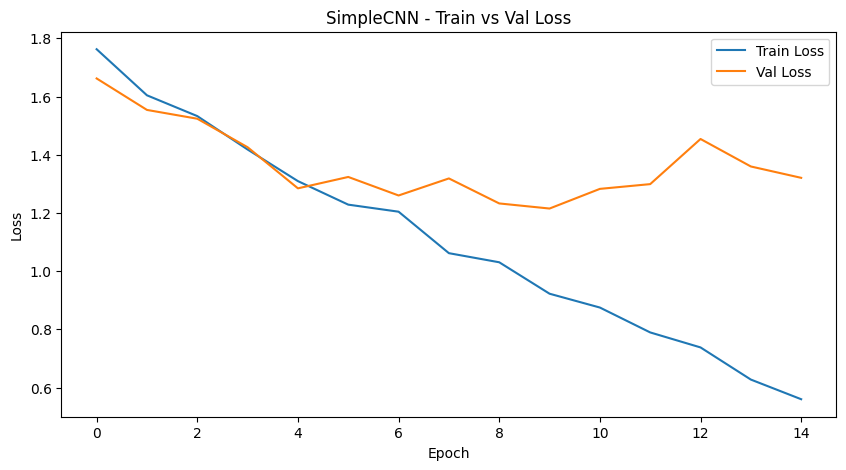

In [43]:
#### TODO ####
plt.figure(figsize=(10, 5))
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SimpleCNN - Train vs Val Loss')
plt.legend()
plt.show()

# Testing

In [45]:
model = SimpleCNN()
model.to(device=device)
model.load_state_dict(best_model)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for i in range(len(test_images)):
        current_test_img = test_images[i]
        current_test_label = test_labels[i]

        img = torch.tensor(current_test_img.copy(), dtype=torch.float32)
        img = img.permute(2, 0, 1)
        img = img / 255.0
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img = (img - mean) / std
        img = torch.nn.functional.interpolate(
            img.unsqueeze(0), size=(128, 128)
        ).squeeze(0)

        img = img.unsqueeze(0).to(device=device, dtype=torch.float32)

        output = model(img)
        pred = torch.argmax(output, dim=1).item()

        all_preds.append(pred)
        all_labels.append(current_test_label.item())

print(f"Testing done. Total: {len(all_preds)} samples")

Testing done. Total: 2005 samples


### Evaluation Metrics ###
Overall accuracy, confusion matrix, and precision, recall, f1 score for each class. 

In [49]:
#### TODO ####
num_classes = 7

# Confusion Matrix
conf_matrix = [[0] * num_classes for _ in range(num_classes)]
for true, pred in zip(all_labels, all_preds):
    conf_matrix[true][pred] += 1

# Overall Accuracy
correct = sum(conf_matrix[i][i] for i in range(num_classes))
total = len(all_labels)
accuracy = correct / total
print(f"Overall Accuracy: {accuracy:.4f}")

# Per-class Precision, Recall, F1
print(f"\n{'Class':<10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 45)

for i in range(num_classes):
    TP = conf_matrix[i][i]
    FP = sum(conf_matrix[j][i] for j in range(num_classes)) - TP  # o sütundakiler - TP
    FN = sum(conf_matrix[i][j] for j in range(num_classes)) - TP  # o satırdakiler - TP

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    print(f"{classDict[i]:<10} {precision:>10.4f} {recall:>10.4f} {f1:>10.4f}")

# Confusion Matrix Plot
print("\nConfusion Matrix:")
print(f"{'':>8}", end="")
for i in range(num_classes):
    print(f"{classDict[i]:>8}", end="")
print()
for i in range(num_classes):
    print(f"{classDict[i]:>8}", end="")
    for j in range(num_classes):
        print(f"{conf_matrix[i][j]:>8}", end="")
    print()

Overall Accuracy: 0.7242

Class       Precision     Recall         F1
---------------------------------------------
akiec          0.3772     0.6515     0.4778
bcc            0.5155     0.8058     0.6288
bkl            0.4949     0.6591     0.5653
df             0.3514     0.5652     0.4333
nv             0.4387     0.6413     0.5209
vasc           0.9643     0.7442     0.8401
mel            0.6923     0.9310     0.7941

Confusion Matrix:
           akiec     bcc     bkl      df      nv    vasc     mel
   akiec      43      13       5       2       3       0       0
     bcc      11      83       2       6       1       0       0
     bkl      29       8     145       5      27       6       0
      df       3       4       1      13       1       1       0
      nv      10       8      28       3     143      29       2
    vasc      18      45     112       8     150     998      10
     mel       0       0       0       0       1       1      27


### RESNET Training ###

In [47]:
# ResNet için dataset - augmentation açık
train_dataset_resnet = DermoDataset(train_images, train_labels, classDict, input_size=(128,128), augmentation=True)
val_dataset_resnet = DermoDataset(val_images, val_labels, classDict, input_size=(128,128))
train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=32, shuffle=True)
val_loader_resnet = DataLoader(val_dataset_resnet, batch_size=32, shuffle=False)
dataloaders_resnet = {'train': train_loader_resnet, 'val': val_loader_resnet}

# Model
model = ResNet50Classifier(3, 7, False)
model.to(device=device)

# Loss + Optimizer
class_counts = np.array([228, 359, 769, 80, 779, 4693, 99], dtype=np.float32)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * 7
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
calc_loss = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

best_model_resnet, train_loss_resnet, val_loss_resnet = train(
    model, dataloaders_resnet, calc_loss, optimizer, numberOfEpoch, early_stop, device, dtype
)

Epoch 0: 100%|██████████| 219/219 [00:30<00:00,  7.10batch/s, loss=1.17]


Epoch 0 | Train Loss: 1.1676 | Train Acc: 0.5934


Epoch 0: 100%|██████████| 32/32 [00:01<00:00, 23.76batch/s, loss=1.08] 


Epoch 0 | Val Loss:   1.0815 | Val Acc:   0.6650
  ✓ Best model saved!


Epoch 1: 100%|██████████| 219/219 [00:25<00:00,  8.68batch/s, loss=0.841]


...

Epoch 5 | Val Loss:   0.8041 | Val Acc:   0.7567
  No improvement 4/5


Epoch 6: 100%|██████████| 219/219 [00:24<00:00,  8.76batch/s, loss=0.387]


Epoch 6 | Train Loss: 0.3870 | Train Acc: 0.8110


Epoch 6: 100%|██████████| 32/32 [00:01<00:00, 27.63batch/s, loss=1.06] 

Epoch 6 | Val Loss:   1.0581 | Val Acc:   0.7876
  No improvement 5/5
Early stopping at epoch 6


### RESNET Test ###

In [48]:
model = ResNet50Classifier(3, 7, False)
model.to(device=device)
model.load_state_dict(best_model_resnet)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for i in range(len(test_images)):
        current_test_img = test_images[i]
        current_test_label = test_labels[i]

        img = torch.tensor(current_test_img.copy(), dtype=torch.float32)
        img = img.permute(2, 0, 1)
        img = img / 255.0
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img = (img - mean) / std
        img = torch.nn.functional.interpolate(
            img.unsqueeze(0), size=(128, 128)
        ).squeeze(0)

        img = img.unsqueeze(0).to(device=device, dtype=torch.float32)

        output = model(img)
        pred = torch.argmax(output, dim=1).item()

        all_preds.append(pred)
        all_labels.append(current_test_label.item())

print(f"Testing done. Total: {len(all_preds)} samples")

Testing done. Total: 2005 samples


### ViT Training ###

In [51]:
# ViT için dataset - 224x224 zorunlu
train_dataset_vit = DermoDataset(train_images, train_labels, classDict, input_size=(224,224), augmentation=True)
val_dataset_vit = DermoDataset(val_images, val_labels, classDict, input_size=(224,224))
train_loader_vit = DataLoader(train_dataset_vit, batch_size=32, shuffle=True)
val_loader_vit = DataLoader(val_dataset_vit, batch_size=32, shuffle=False)
dataloaders_vit = {'train': train_loader_vit, 'val': val_loader_vit}

# Model
model = Vit16Classifier(3, 7, False)
model.to(device=device)

# Loss + Optimizer
class_counts = np.array([228, 359, 769, 80, 779, 4693, 99], dtype=np.float32)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * 7
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
calc_loss = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

best_model_vit, train_loss_vit, val_loss_vit = train(
    model, dataloaders_vit, calc_loss, optimizer, numberOfEpoch, early_stop, device, dtype
)

Epoch 0: 100%|██████████| 219/219 [03:07<00:00,  1.17batch/s, loss=1.58]


Epoch 0 | Train Loss: 1.5763 | Train Acc: 0.4443


Epoch 0: 100%|██████████| 32/32 [00:08<00:00,  3.70batch/s, loss=1.22]


Epoch 0 | Val Loss:   1.2194 | Val Acc:   0.5713
  ✓ Best model saved!


Epoch 1: 100%|██████████| 219/219 [03:07<00:00,  1.17batch/s, loss=1.19]


...

Epoch 7 | Val Loss:   0.8457 | Val Acc:   0.6401
  No improvement 4/5


Epoch 8: 100%|██████████| 219/219 [03:02<00:00,  1.20batch/s, loss=0.603]


Epoch 8 | Train Loss: 0.6027 | Train Acc: 0.7170


Epoch 8: 100%|██████████| 32/32 [00:08<00:00,  3.84batch/s, loss=0.81] 

Epoch 8 | Val Loss:   0.8100 | Val Acc:   0.8016
  No improvement 5/5
Early stopping at epoch 8


### ViT Testing ###

In [ ]:
model = Vit16Classifier(3, 7, False)
model.to(device=device)
model.load_state_dict(best_model_vit)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for i in range(len(test_images)):
        current_test_img = test_images[i]
        current_test_label = test_labels[i]

        img = torch.tensor(current_test_img.copy(), dtype=torch.float32)
        img = img.permute(2, 0, 1)
        img = img / 255.0
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img = (img - mean) / std
        img = torch.nn.functional.interpolate(
            img.unsqueeze(0), size=(224, 224)  # ViT için 224x224
        ).squeeze(0)

        img = img.unsqueeze(0).to(device=device, dtype=torch.float32)

        output = model(img)
        pred = torch.argmax(output, dim=1).item()

        all_preds.append(pred)
        all_labels.append(current_test_label.item())

print(f"Testing done. Total: {len(all_preds)} samples")

### Plotting Results ###

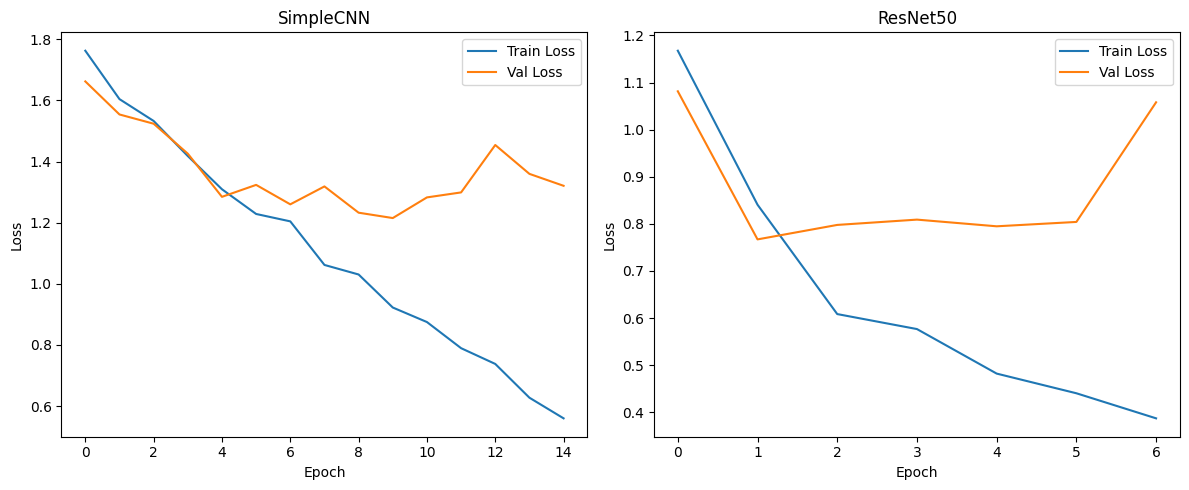

In [ ]:
plt.figure(figsize=(18, 5))

# SimpleCNN
plt.subplot(1, 3, 1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.title('SimpleCNN')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# ResNet50
plt.subplot(1, 3, 2)
plt.plot(train_loss_resnet, label='Train Loss')
plt.plot(val_loss_resnet, label='Val Loss')
plt.title('ResNet50')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# ViT
plt.subplot(1, 3, 3)
plt.plot(train_loss_vit, label='Train Loss')
plt.plot(val_loss_vit, label='Val Loss')
plt.title('ViT')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()